# Galpy Force Accuracy Near R=0

Galpy evaluates forces in cylindrical coordinates (`Rforce`, `phitorque`, `zforce`).
At R=0, `phitorque/R` → `0/0 = NaN`, and force direction becomes undefined.

This notebook compares the **bridge acceleration** (galpy cylindrical → Cartesian) against
**numerical** `-grad(Phi)` (central differences on the potential) as a function of distance
from the z-axis.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import warnings
from functools import partial
from galpy.potential import (
    NFWPotential, PlummerPotential, HernquistPotential, KeplerPotential
)
from ezfalconv2.util import galpy as galpy_util

plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

In [2]:
def numerical_acc(pot_fn, pos, h=1e-5):
    """Compute -grad(Phi) via central differences."""
    pos = np.asarray(pos, dtype=float)
    acc = np.zeros_like(pos)
    for i in range(3):
        pos_plus = pos.copy()
        pos_minus = pos.copy()
        pos_plus[:, i] += h
        pos_minus[:, i] -= h
        acc[:, i] = -(pot_fn(pos_plus) - pot_fn(pos_minus)) / (2 * h)
    return acc

## Approaching the z-axis along x at fixed z

We place test particles at `(x, 0, z_fixed)` and sweep `x` from large values down toward 0.

In [3]:
potentials = {
    'NFW': NFWPotential(amp=1e12*u.Msun, a=20*u.kpc),
    'Plummer': PlummerPotential(amp=1e12*u.Msun, b=10*u.kpc),
    'Hernquist': HernquistPotential(amp=1e12*u.Msun, a=20*u.kpc),
    'Kepler': KeplerPotential(amp=1e12*u.Msun),
}
for p in potentials.values():
    p.turn_physical_on()

# x values approaching 0
x_vals = np.geomspace(1e-14, 10, 200)
z_fixed = 5.0  # kpc

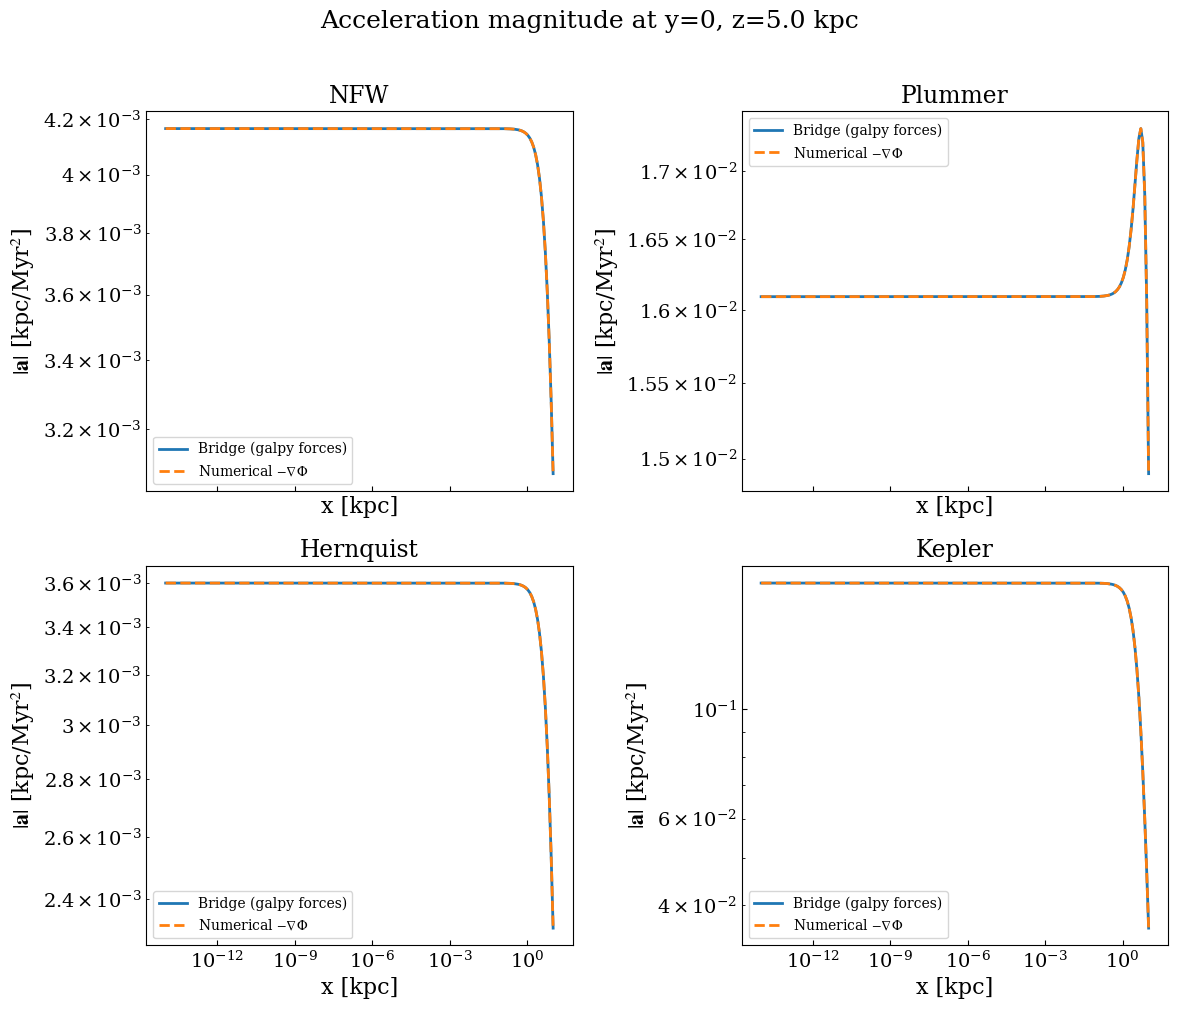

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

for ax, (name, pot) in zip(axes.flat, potentials.items()):
    acc_fn = galpy_util._galpy_pot_to_acc_fn(pot)
    pot_fn = galpy_util._galpy_pot_to_pot_fn(pot)
    pot_i = partial(pot_fn, t=0)

    # Positions: (x, 0, z_fixed)
    pos = np.column_stack([x_vals, np.zeros_like(x_vals), np.full_like(x_vals, z_fixed)])

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        acc_bridge = acc_fn(pos, t=0)
        acc_num = numerical_acc(pot_i, pos)

    # Acceleration magnitude
    mag_bridge = np.linalg.norm(acc_bridge, axis=1)
    mag_num = np.linalg.norm(acc_num, axis=1)

    ax.loglog(x_vals, mag_bridge, label='Bridge (galpy forces)', lw=2)
    ax.loglog(x_vals, mag_num, '--', label=r'Numerical $-\nabla\Phi$', lw=2)
    ax.set_title(name)
    ax.set_ylabel(r'$|\mathbf{a}|$ [kpc/Myr$^2$]')
    ax.set_xlabel('x [kpc]')
    ax.legend(fontsize=10)

fig.suptitle(f'Acceleration magnitude at y=0, z={z_fixed} kpc', fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

## Relative error vs distance from z-axis

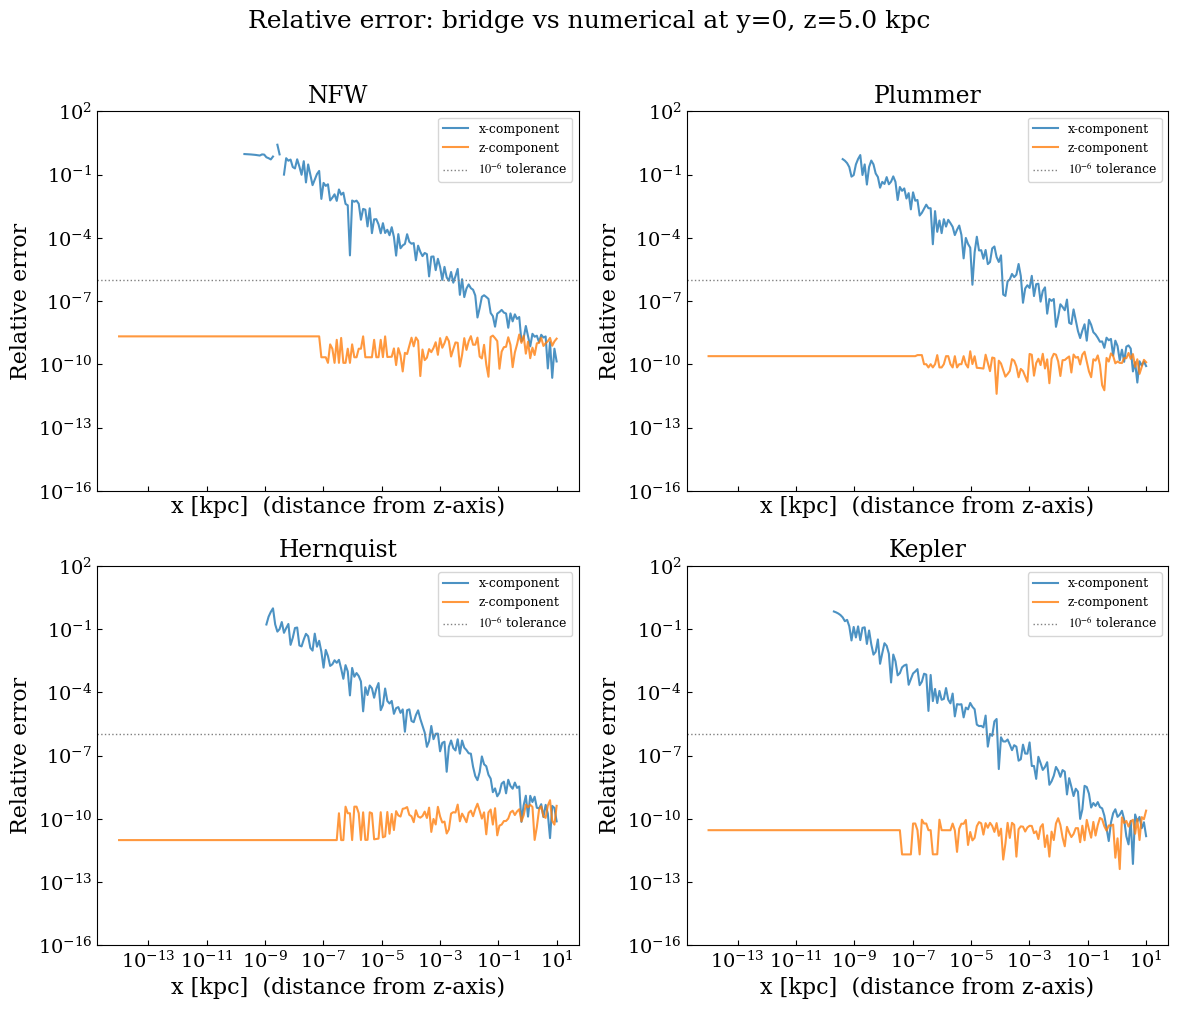

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

for ax, (name, pot) in zip(axes.flat, potentials.items()):
    acc_fn = galpy_util._galpy_pot_to_acc_fn(pot)
    pot_fn = galpy_util._galpy_pot_to_pot_fn(pot)
    pot_i = partial(pot_fn, t=0)

    pos = np.column_stack([x_vals, np.zeros_like(x_vals), np.full_like(x_vals, z_fixed)])

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        acc_bridge = acc_fn(pos, t=0)
        acc_num = numerical_acc(pot_i, pos)

    # Per-component relative error
    denom = np.abs(acc_num)
    denom = np.where(denom > 1e-30, denom, np.nan)
    rel_err = np.abs(acc_bridge - acc_num) / denom

    ax.loglog(x_vals, rel_err[:, 0], label='x-component', alpha=0.8)
    ax.loglog(x_vals, rel_err[:, 2], label='z-component', alpha=0.8)
    ax.axhline(1e-6, color='gray', ls=':', lw=1, label=r'$10^{-6}$ tolerance')
    ax.set_title(name)
    ax.set_ylabel('Relative error')
    ax.set_xlabel('x [kpc]  (distance from z-axis)')
    ax.legend(fontsize=9)
    ax.set_ylim(1e-16, 1e2)

fig.suptitle(f'Relative error: bridge vs numerical at y=0, z={z_fixed} kpc', fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

## Approaching the origin along x=y=z diagonal

<>:25: SyntaxWarning: invalid escape sequence '\m'

<>:25: SyntaxWarning: invalid escape sequence '\m'

/var/folders/s1/bxkg8f1501g2q16qjhch2_qw0000gn/T/ipykernel_56184/502633200.py:25: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Relative error in $|\mathbf{a}|$')



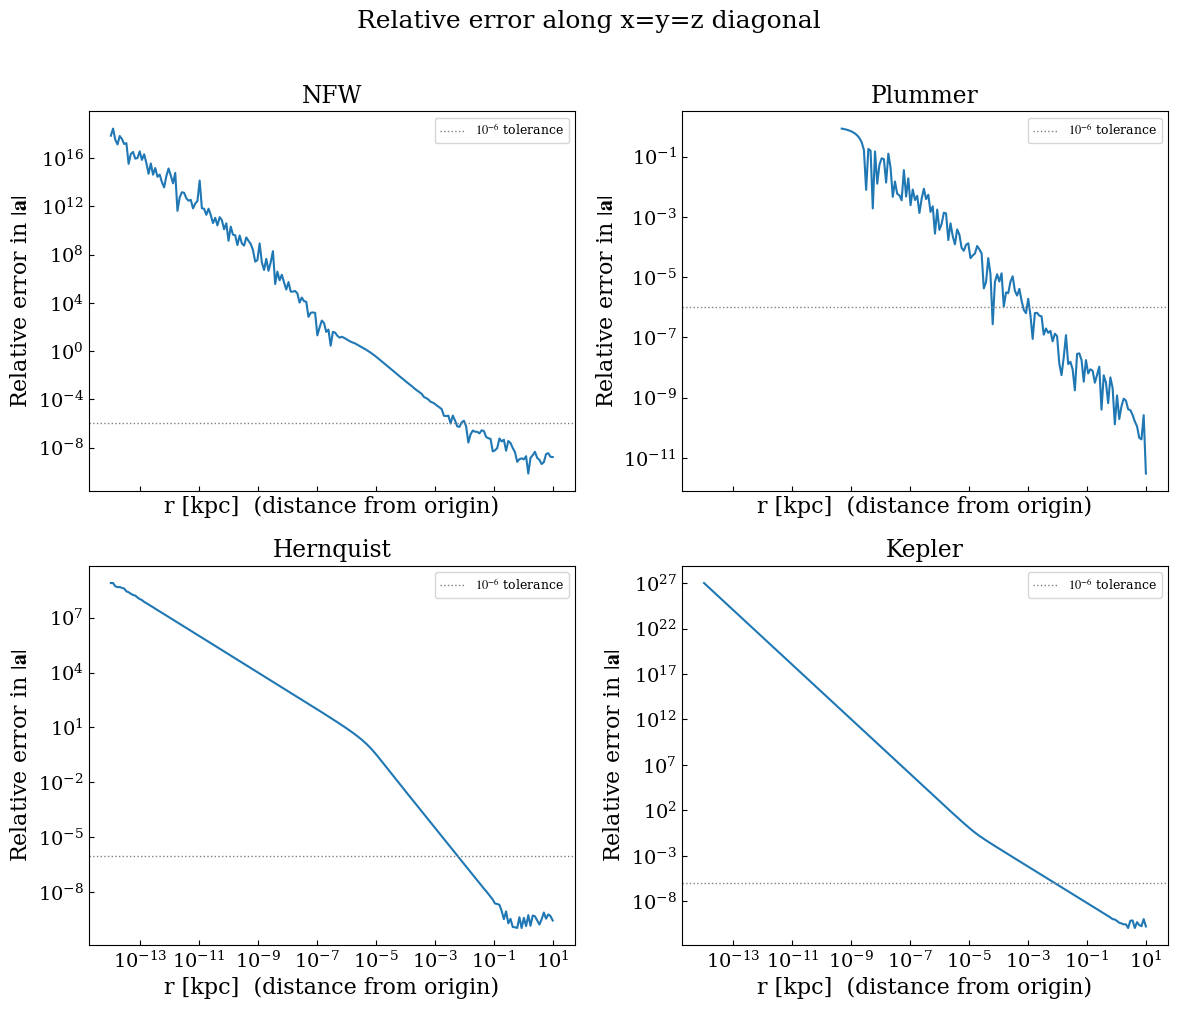

In [8]:
r_vals = np.geomspace(1e-14, 10, 200)
# Diagonal positions: x = y = z = r/sqrt(3)
diag = r_vals / np.sqrt(3)
pos_diag = np.column_stack([diag, diag, diag])

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

for ax, (name, pot) in zip(axes.flat, potentials.items()):
    acc_fn = galpy_util._galpy_pot_to_acc_fn(pot)
    pot_fn = galpy_util._galpy_pot_to_pot_fn(pot)
    pot_i = partial(pot_fn, t=0)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        acc_bridge = acc_fn(pos_diag, t=0)
        acc_num = numerical_acc(pot_i, pos_diag)

    mag_bridge = np.linalg.norm(acc_bridge, axis=1)
    mag_num = np.linalg.norm(acc_num, axis=1)
    rel_err = np.abs(mag_bridge - mag_num) / np.where(mag_num > 1e-30, mag_num, np.nan)

    ax.loglog(r_vals, rel_err)
    ax.axhline(1e-6, color='gray', ls=':', lw=1, label=r'$10^{-6}$ tolerance')
    ax.set_title(name)
    ax.set_ylabel('Relative error in $|\mathbf{a}|$')
    ax.set_xlabel('r [kpc]  (distance from origin)')
    ax.legend(fontsize=9)
    # ax.set_ylim(1e-16, 1e2)

fig.suptitle('Relative error along x=y=z diagonal', fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

## Exactly on the z-axis (x=0, y=0)

This is where galpy produces NaN due to `phitorque/R = 0/0`.

In [9]:
z_vals = np.geomspace(1e-10, 100, 200)
pos_zaxis = np.column_stack([np.zeros_like(z_vals), np.zeros_like(z_vals), z_vals])

for name, pot in potentials.items():
    acc_fn = galpy_util._galpy_pot_to_acc_fn(pot)
    pot_fn = galpy_util._galpy_pot_to_pot_fn(pot)
    pot_i = partial(pot_fn, t=0)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        acc_bridge = acc_fn(pos_zaxis, t=0)
        acc_num = numerical_acc(pot_i, pos_zaxis)

    nan_count = np.isnan(acc_bridge).any(axis=1).sum()
    print(f'{name}: {nan_count}/{len(z_vals)} z-axis points have NaN in bridge acceleration')
    print(f'  Numerical acc is finite: {np.all(np.isfinite(acc_num))}')
    print(f'  Bridge ax range: [{np.nanmin(acc_bridge[:,0]):.3e}, {np.nanmax(acc_bridge[:,0]):.3e}]')
    print(f'  Numerical ax range: [{acc_num[:,0].min():.3e}, {acc_num[:,0].max():.3e}]')
    print()

NFW: 200/200 z-axis points have NaN in bridge acceleration
  Numerical acc is finite: True
/var/folders/s1/bxkg8f1501g2q16qjhch2_qw0000gn/T/ipykernel_56184/283412638.py:17: RuntimeWarning: All-NaN slice encountered
  print(f'  Bridge ax range: [{np.nanmin(acc_bridge[:,0]):.3e}, {np.nanmax(acc_bridge[:,0]):.3e}]')

  Bridge ax range: [nan, nan]
  Numerical ax range: [-0.000e+00, -0.000e+00]

Plummer: 200/200 z-axis points have NaN in bridge acceleration
  Numerical acc is finite: True
/var/folders/s1/bxkg8f1501g2q16qjhch2_qw0000gn/T/ipykernel_56184/283412638.py:17: RuntimeWarning: All-NaN slice encountered
  print(f'  Bridge ax range: [{np.nanmin(acc_bridge[:,0]):.3e}, {np.nanmax(acc_bridge[:,0]):.3e}]')

  Bridge ax range: [nan, nan]
  Numerical ax range: [-0.000e+00, -0.000e+00]

Hernquist: 200/200 z-axis points have NaN in bridge acceleration
  Numerical acc is finite: True
/var/folders/s1/bxkg8f1501g2q16qjhch2_qw0000gn/T/ipykernel_56184/283412638.py:17: RuntimeWarning: All-NaN slice

## Critical radius: where does relative error exceed $10^{-6}$?

For each supported galpy potential, we sweep along the $x = y = z$ diagonal toward the origin
and find the largest radius where the relative error between bridge and numerical acceleration
first exceeds $10^{-6}$.

In [16]:
from galpy.potential import (
    BurkertPotential, DehnenCoreSphericalPotential, DehnenSphericalPotential,
    EinastoPotential, HernquistPotential, IsochronePotential,
    JaffePotential, KeplerPotential, KingPotential, NFWPotential,
    PlummerPotential, PowerSphericalPotential, PowerSphericalPotentialwCutoff,
    PseudoIsothermalPotential, TwoPowerSphericalPotential, KuzminDiskPotential,
)

all_potentials = {
    'BurkertPotential': BurkertPotential(),
    'DehnenCoreSphericalPotential': DehnenCoreSphericalPotential(),
    'DehnenSphericalPotential': DehnenSphericalPotential(),
    'EinastoPotential': EinastoPotential(),
    'HernquistPotential': HernquistPotential(),
    'IsochronePotential': IsochronePotential(),
    'JaffePotential': JaffePotential(),
    'KeplerPotential': KeplerPotential(),
    'KingPotential': KingPotential(),
    'NFWPotential': NFWPotential(),
    'PlummerPotential': PlummerPotential(),
    'PowerSphericalPotential': PowerSphericalPotential(),
    'PowerSphericalPotentialwCutoff': PowerSphericalPotentialwCutoff(),
    'PseudoIsothermalPotential': PseudoIsothermalPotential(),
    'TwoPowerSphericalPotential': TwoPowerSphericalPotential(),
    'KuzminDiskPotential': KuzminDiskPotential(),
}
for p in all_potentials.values():
    p.turn_physical_on()

# Sweep along x=y=z diagonal from 100 kpc down to 1e-14 kpc
r_sweep = np.geomspace(1e-14, 100, 500)
diag_sweep = r_sweep / np.sqrt(3)
pos_sweep = np.column_stack([diag_sweep, diag_sweep, diag_sweep])

threshold = 1e-6
results = {}

for name, pot in all_potentials.items():
    acc_fn = galpy_util._galpy_pot_to_acc_fn(pot)
    pot_fn = galpy_util._galpy_pot_to_pot_fn(pot)
    pot_i = partial(pot_fn, t=0)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        acc_bridge = acc_fn(pos_sweep, t=0)
        acc_num = numerical_acc(pot_i, pos_sweep)

    mag_bridge = np.linalg.norm(acc_bridge, axis=1)
    mag_num = np.linalg.norm(acc_num, axis=1)

    # Relative error in acceleration magnitude
    good = mag_num > 1e-30
    rel_err = np.full_like(r_sweep, np.nan)
    rel_err[good] = np.abs(mag_bridge[good] - mag_num[good]) / mag_num[good]

    # Find the largest r where error exceeds threshold or result is NaN/inf
    bad = np.where(good & ((rel_err > threshold) | np.isnan(mag_bridge).any(axis=None)))[0]
    r_crit = r_sweep[bad.max()] if len(bad) > 0 else None

    # Also check for NaN in bridge
    nan_mask = np.isnan(acc_bridge).any(axis=1)
    r_nan = r_sweep[nan_mask].max() if nan_mask.any() else None

    results[name] = {'r_crit': r_crit, 'r_nan': r_nan}

# Print results as a table
print(f"{'Potential':<38} {'r_crit (err > 1e-6) [kpc]':>28} {'r_nan [kpc]':>14}")
print('-' * 82)
for name, res in sorted(results.items()):
    r_crit_str = f"{res['r_crit']:.2e}" if res['r_crit'] is not None else 'always < 1e-6'
    r_nan_str = f"{res['r_nan']:.2e}" if res['r_nan'] is not None else 'None'
    print(f"{name:<38} {r_crit_str:>28} {r_nan_str:>14}")

Potential                                 r_crit (err > 1e-6) [kpc]    r_nan [kpc]
----------------------------------------------------------------------------------
BurkertPotential                                           3.66e-01           None
DehnenCoreSphericalPotential                               3.29e-04           None
DehnenSphericalPotential                                   6.30e-03           None
EinastoPotential                                           2.53e-01           None
HernquistPotential                                         5.44e-03           None
IsochronePotential                                         2.60e-03           None
JaffePotential                                             7.31e-03           None
KeplerPotential                                            7.87e-03           None
KingPotential                                              1.82e-04           None
KuzminDiskPotential                                        1.72e-05           None
NFWP

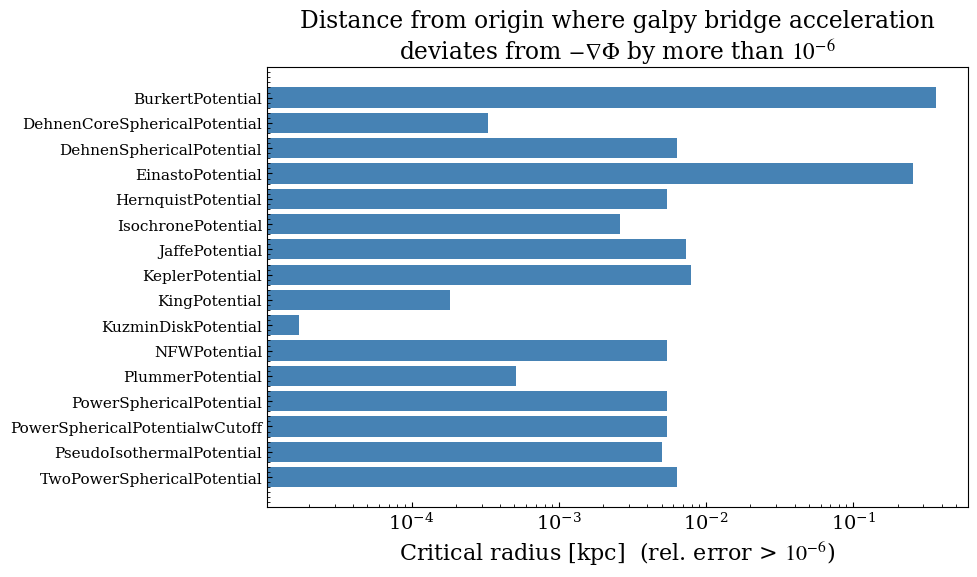

In [17]:
# Bar chart of critical radii
names = [n for n, r in sorted(results.items()) if r['r_crit'] is not None]
r_crits = [results[n]['r_crit'] for n in names]

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(names))
ax.barh(y_pos, r_crits, color='steelblue')
ax.set_yticks(y_pos)
ax.set_yticklabels(names, fontsize=11)
ax.set_xscale('log')
ax.set_xlabel('Critical radius [kpc]  (rel. error > $10^{-6}$)')
ax.set_title('Distance from origin where galpy bridge acceleration\ndeviates from $-\\nabla\\Phi$ by more than $10^{-6}$')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Axisymmetric potentials (non-spherical)

Same analysis along the x=y=z diagonal for axisymmetric disk/halo potentials.

In [18]:
from galpy.potential import (
    MiyamotoNagaiPotential, DoubleExponentialDiskPotential,
    RazorThinExponentialDiskPotential, LogarithmicHaloPotential,
    FlattenedPowerPotential, MN3ExponentialDiskPotential,
    KuzminKutuzovStaeckelPotential, RingPotential,
    SCFPotential, IsothermalDiskPotential,
)

axisymmetric_potentials = {
    'MiyamotoNagaiPotential': MiyamotoNagaiPotential(),
    'DoubleExponentialDiskPotential': DoubleExponentialDiskPotential(),
    'RazorThinExponentialDiskPotential': RazorThinExponentialDiskPotential(),
    'LogarithmicHaloPotential (q=0.8)': LogarithmicHaloPotential(q=0.8),
    'FlattenedPowerPotential': FlattenedPowerPotential(),
    'MN3ExponentialDiskPotential': MN3ExponentialDiskPotential(),
    'KuzminKutuzovStaeckelPotential': KuzminKutuzovStaeckelPotential(),
    'RingPotential': RingPotential(),
    'SCFPotential': SCFPotential(),
    'IsothermalDiskPotential': IsothermalDiskPotential(),
}
for p in axisymmetric_potentials.values():
    p.turn_physical_on()

axi_results = {}
for name, pot in axisymmetric_potentials.items():
    acc_fn = galpy_util._galpy_pot_to_acc_fn(pot)
    pot_fn = galpy_util._galpy_pot_to_pot_fn(pot)
    pot_i = partial(pot_fn, t=0)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            acc_bridge = acc_fn(pos_sweep, t=0)
            acc_num = numerical_acc(pot_i, pos_sweep)
    except (TypeError, ValueError, AttributeError) as e:
        print(f'{name}: SKIPPED ({type(e).__name__})')
        axi_results[name] = {'r_crit': None, 'r_nan': None, 'skipped': True}
        continue

    mag_bridge = np.linalg.norm(acc_bridge, axis=1)
    mag_num = np.linalg.norm(acc_num, axis=1)

    good = mag_num > 1e-30
    rel_err = np.full_like(r_sweep, np.nan)
    rel_err[good] = np.abs(mag_bridge[good] - mag_num[good]) / mag_num[good]

    bad = np.where(good & ((rel_err > threshold) | np.isnan(mag_bridge).any(axis=None)))[0]
    r_crit = r_sweep[bad.max()] if len(bad) > 0 else None

    nan_mask = np.isnan(acc_bridge).any(axis=1)
    r_nan = r_sweep[nan_mask].max() if nan_mask.any() else None
    axi_results[name] = {'r_crit': r_crit, 'r_nan': r_nan, 'skipped': False}

print(f"\n{'Potential':<42} {'r_crit (err > 1e-6) [kpc]':>28} {'r_nan [kpc]':>14}")
print('-' * 86)
for name, res in sorted(axi_results.items()):
    if res.get('skipped'):
        print(f"{name:<42} {'SKIPPED (scalar only)':>28} {'':>14}")
    else:
        r_crit_str = f"{res['r_crit']:.2e}" if res['r_crit'] is not None else 'always < 1e-6'
        r_nan_str = f"{res['r_nan']:.2e}" if res['r_nan'] is not None else 'None'
        print(f"{name:<42} {r_crit_str:>28} {r_nan_str:>14}")

/Users/gabrielpfaffman/Repos/misc/galpy/galpy/potential/DoubleExponentialDiskPotential.py:19: RuntimeWarning: overflow encountered in sinh
  return (numpy.sinh(numpy.pi * numpy.sinh(t)) + numpy.pi * t * numpy.cosh(t)) / (

/Users/gabrielpfaffman/Repos/misc/galpy/galpy/potential/DoubleExponentialDiskPotential.py:20: RuntimeWarning: overflow encountered in cosh
  numpy.cosh(numpy.pi * numpy.sinh(t)) + 1

/Users/gabrielpfaffman/Repos/misc/galpy/galpy/potential/DoubleExponentialDiskPotential.py:19: RuntimeWarning: invalid value encountered in divide
  return (numpy.sinh(numpy.pi * numpy.sinh(t)) + numpy.pi * t * numpy.cosh(t)) / (

DoubleExponentialDiskPotential: SKIPPED (TypeError)
RazorThinExponentialDiskPotential: SKIPPED (ValueError)
IsothermalDiskPotential: SKIPPED (AttributeError)

Potential                                     r_crit (err > 1e-6) [kpc]    r_nan [kpc]
--------------------------------------------------------------------------------------
DoubleExponentialDiskPotential 

## Triaxial and non-axisymmetric potentials

These have `isNonAxi=True` — the phi-dependence means `phitorque` is nonzero, making the `phitorque/R` singularity worse.
We set `b != 1, c != 1` for the triaxial family so they are truly non-spherical.

In [19]:
from galpy.potential import (
    TriaxialHernquistPotential, TriaxialNFWPotential, TriaxialJaffePotential,
    TwoPowerTriaxialPotential, PerfectEllipsoidPotential,
    FerrersPotential, DehnenBarPotential, SoftenedNeedleBarPotential,
    SpiralArmsPotential, LogarithmicHaloPotential,
)

triaxial_potentials = {
    'TriaxialHernquistPotential': TriaxialHernquistPotential(b=0.8, c=0.6),
    'TriaxialNFWPotential': TriaxialNFWPotential(b=0.8, c=0.6),
    'TriaxialJaffePotential': TriaxialJaffePotential(b=0.8, c=0.6),
    'TwoPowerTriaxialPotential': TwoPowerTriaxialPotential(b=0.8, c=0.6),
    'PerfectEllipsoidPotential': PerfectEllipsoidPotential(b=0.8, c=0.6),
    'FerrersPotential': FerrersPotential(),
    'DehnenBarPotential': DehnenBarPotential(),
    'SoftenedNeedleBarPotential': SoftenedNeedleBarPotential(),
    'SpiralArmsPotential': SpiralArmsPotential(),
    'LogarithmicHaloPotential (triaxial)': LogarithmicHaloPotential(b=0.8, q=0.7),
}
for p in triaxial_potentials.values():
    p.turn_physical_on()

tri_results = {}
for name, pot in triaxial_potentials.items():
    acc_fn = galpy_util._galpy_pot_to_acc_fn(pot)
    pot_fn = galpy_util._galpy_pot_to_pot_fn(pot)
    pot_i = partial(pot_fn, t=0)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            acc_bridge = acc_fn(pos_sweep, t=0)
            acc_num = numerical_acc(pot_i, pos_sweep)
    except (TypeError, ValueError, AttributeError) as e:
        print(f'{name}: SKIPPED ({type(e).__name__})')
        tri_results[name] = {'r_crit': None, 'r_nan': None, 'skipped': True}
        continue

    mag_bridge = np.linalg.norm(acc_bridge, axis=1)
    mag_num = np.linalg.norm(acc_num, axis=1)

    good = mag_num > 1e-30
    rel_err = np.full_like(r_sweep, np.nan)
    rel_err[good] = np.abs(mag_bridge[good] - mag_num[good]) / mag_num[good]

    bad = np.where(good & ((rel_err > threshold) | np.isnan(mag_bridge).any(axis=None)))[0]
    r_crit = r_sweep[bad.max()] if len(bad) > 0 else None

    nan_mask = np.isnan(acc_bridge).any(axis=1)
    r_nan = r_sweep[nan_mask].max() if nan_mask.any() else None
    tri_results[name] = {'r_crit': r_crit, 'r_nan': r_nan, 'skipped': False}

print(f"{'Potential':<42} {'r_crit (err > 1e-6) [kpc]':>28} {'r_nan [kpc]':>14}")
print('-' * 86)
for name, res in sorted(tri_results.items()):
    if res.get('skipped'):
        print(f"{name:<42} {'SKIPPED (scalar only)':>28} {'':>14}")
    else:
        r_crit_str = f"{res['r_crit']:.2e}" if res['r_crit'] is not None else 'always < 1e-6'
        r_nan_str = f"{res['r_nan']:.2e}" if res['r_nan'] is not None else 'None'
        print(f"{name:<42} {r_crit_str:>28} {r_nan_str:>14}")

TriaxialHernquistPotential: SKIPPED (TypeError)
TriaxialNFWPotential: SKIPPED (TypeError)
TriaxialJaffePotential: SKIPPED (TypeError)
TwoPowerTriaxialPotential: SKIPPED (TypeError)
PerfectEllipsoidPotential: SKIPPED (TypeError)
FerrersPotential: SKIPPED (ValueError)
SoftenedNeedleBarPotential: SKIPPED (ValueError)
Potential                                     r_crit (err > 1e-6) [kpc]    r_nan [kpc]
--------------------------------------------------------------------------------------
DehnenBarPotential                                             5.86e-03           None
FerrersPotential                                  SKIPPED (scalar only)               
LogarithmicHaloPotential (triaxial)                            7.31e-03           None
PerfectEllipsoidPotential                         SKIPPED (scalar only)               
SoftenedNeedleBarPotential                        SKIPPED (scalar only)               
SpiralArmsPotential                                            3.71e-02    

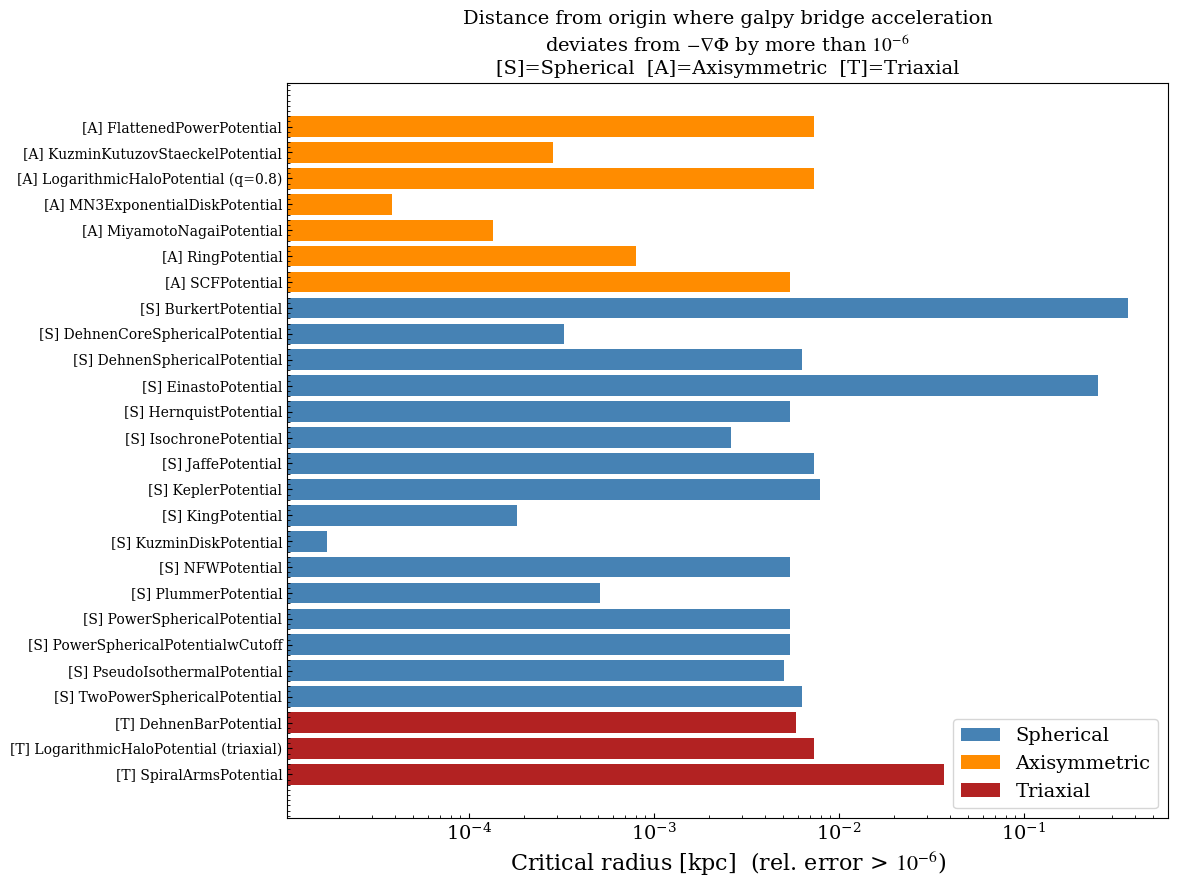

In [20]:
# Combined bar chart: all three categories
all_results = {}
for name, res in results.items():
    all_results[f'[S] {name}'] = res
for name, res in axi_results.items():
    if not res.get('skipped'):
        all_results[f'[A] {name}'] = res
for name, res in tri_results.items():
    if not res.get('skipped'):
        all_results[f'[T] {name}'] = res

names_all = [n for n, r in sorted(all_results.items()) if r['r_crit'] is not None]
r_crits_all = [all_results[n]['r_crit'] for n in names_all]

# Color by category
colors = []
for n in names_all:
    if n.startswith('[S]'):
        colors.append('steelblue')
    elif n.startswith('[A]'):
        colors.append('darkorange')
    else:
        colors.append('firebrick')

fig, ax = plt.subplots(figsize=(12, max(8, len(names_all) * 0.35)))
y_pos = np.arange(len(names_all))
ax.barh(y_pos, r_crits_all, color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(names_all, fontsize=10)
ax.set_xscale('log')
ax.set_xlabel('Critical radius [kpc]  (rel. error > $10^{-6}$)')
ax.set_title('Distance from origin where galpy bridge acceleration\n'
             r'deviates from $-\nabla\Phi$ by more than $10^{-6}$'
             '\n[S]=Spherical  [A]=Axisymmetric  [T]=Triaxial', fontsize=14)
ax.invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Spherical'),
                   Patch(facecolor='darkorange', label='Axisymmetric'),
                   Patch(facecolor='firebrick', label='Triaxial')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()